# Merge, Join and Concatination of Dataframes using Pandas
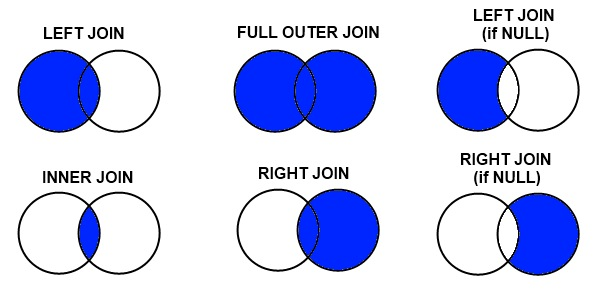

In [ ]:
import pandas as pd

In [ ]:
df2=pd.read_csv("/content/LOTR.csv")
df2

,FellowshipID,FirstName,Skills
0,1001,Frodo,Hiding
1,1002,Samwise,Gardening
2,1003,Gandalf,Spells
3,1004,Pippin,Fireworks


In [ ]:
df1=pd.read_csv("/content/LOTR 2.csv")
df1

,FellowshipID,FirstName,Age
0,1001,Frodo,50
1,1002,Samwise,39
2,1006,Legolas,2931
3,1007,Elrond,6520
4,1008,Barromir,51


In [ ]:
df1.merge(df2)
#Perform inner join by default if how not defined explicitly
# merging on common columns 'FellowshipID' and 'FirstName' as keys.

,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50,Hiding
1,1002,Samwise,39,Gardening


In [ ]:
df1.merge(df2, how='inner',on=['FellowshipID', 'FirstName'])
# Multiple columns can be passed to the 'on' parameter as a list.

,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50,Hiding
1,1002,Samwise,39,Gardening


In [ ]:
df1.merge(df2, how='inner',on=['FellowshipID'])
# When merging on 'FellowshipID' only, and both dataframes have a 'FirstName' column, pandas renames the conflicting columns to 'FirstName_x' (from df1) and 'FirstName_y' (from df2).

,FellowshipID,FirstName_x,Age,FirstName_y,Skills
0,1001,Frodo,50,Frodo,Hiding
1,1002,Samwise,39,Samwise,Gardening


In [ ]:
df1.merge(df2, how='outer')
# An 'outer' merge includes all rows from both dataframes, and fills unmatched columns with NaN values.

,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50.0,Hiding
1,1002,Samwise,39.0,Gardening
2,1003,Gandalf,NaN,Spells
3,1004,Pippin,NaN,Fireworks
4,1006,Legolas,2931.0,NaN
5,1007,Elrond,6520.0,NaN
6,1008,Barromir,51.0,NaN


In [ ]:
df1.merge(df2, how='left')
# A 'left' merge includes all rows from the left DataFrame (df1) and only the matching rows from the right DataFrame (df2).
# Unmatched columns from the right DataFrame are filled with NaN values.

,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50,Hiding
1,1002,Samwise,39,Gardening
2,1006,Legolas,2931,NaN
3,1007,Elrond,6520,NaN
4,1008,Barromir,51,NaN


In [ ]:
df1.columns, df2.columns

(Index(['FellowshipID', 'FirstName', 'Age'], dtype='object'),
 Index(['FellowshipID', 'FirstName', 'Skills'], dtype='object'))

In [ ]:
df1.merge(df2, how='right')


,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50.0,Hiding
1,1002,Samwise,39.0,Gardening
2,1003,Gandalf,NaN,Spells
3,1004,Pippin,NaN,Fireworks


In [ ]:
df2.merge(df1, how='left')


,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN


In [ ]:
df2.merge(df1, how='cross')


,FellowshipID_x,FirstName_x,Skills,FellowshipID_y,FirstName_y,Age
0,1001,Frodo,Hiding,1001,Frodo,50
1,1001,Frodo,Hiding,1002,Samwise,39
2,1001,Frodo,Hiding,1006,Legolas,2931
3,1001,Frodo,Hiding,1007,Elrond,6520
4,1001,Frodo,Hiding,1008,Barromir,51
5,1002,Samwise,Gardening,1001,Frodo,50
6,1002,Samwise,Gardening,1002,Samwise,39
7,1002,Samwise,Gardening,1006,Legolas,2931
8,1002,Samwise,Gardening,1007,Elrond,6520
9,1002,Samwise,Gardening,1008,Barromir,51


In [ ]:
df2.merge(df1, how='cross').shape

(20, 6)

In [ ]:
# The 'join' method combines DataFrames based on their indexes or a specified column.
# In this case, it performs an outer join using 'FellowshipID' from df1 as the key.
# 'how='outer'' ensures all rows from both DataFrames are included.
# 'lsuffix='_left'' and 'rsuffix='_right'' are used to differentiate columns with the same name (like 'FellowshipID') from the left and right DataFrames respectively.
# It's important to note that when using 'on' with 'join', the specified column ('FellowshipID') must be an index in the right DataFrame (df2) or a key in the left DataFrame (df1).
df1.join(df2, on='FellowshipID',how='outer', lsuffix='_left', rsuffix='_right')

,FellowshipID,FellowshipID_left,FirstName_left,Age,FellowshipID_right,FirstName_right,Skills
NaN,0,NaN,NaN,NaN,1001.0,Frodo,Hiding
NaN,1,NaN,NaN,NaN,1002.0,Samwise,Gardening
NaN,2,NaN,NaN,NaN,1003.0,Gandalf,Spells
NaN,3,NaN,NaN,NaN,1004.0,Pippin,Fireworks
0.0,1001,1001.0,Frodo,50.0,NaN,NaN,NaN
1.0,1002,1002.0,Samwise,39.0,NaN,NaN,NaN
2.0,1006,1006.0,Legolas,2931.0,NaN,NaN,NaN
3.0,1007,1007.0,Elrond,6520.0,NaN,NaN,NaN
4.0,1008,1008.0,Barromir,51.0,NaN,NaN,NaN


In [ ]:
# This line performs a join operation between df1 and df2.
# First, it sets 'FellowshipID' as the index for both DataFrames.
# Then, it joins them based on their common index.
# 'lsuffix' and 'rsuffix' are used to distinguish columns that have the same name (e.g., 'FirstName') in both original DataFrames.
dfn=df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'), lsuffix='_left', rsuffix='_right')
dfn

,FirstName_left,Age,FirstName_right,Skills
FellowshipID,,,,
1001,Frodo,50,Frodo,Hiding
1002,Samwise,39,Samwise,Gardening
1006,Legolas,2931,NaN,NaN
1007,Elrond,6520,NaN,NaN
1008,Barromir,51,NaN,NaN


In [ ]:
# Accessing the value 1001 from 'FellowshipID' column at index 0 using .loc
df1.loc[0, 'FellowshipID']

np.int64(1001)

# pandas merge() vs join(): Key Differences

In pandas, the core difference is that the `merge()` function is more flexible, defaulting to joining on common columns (like SQL joins), while the `join()` method is a convenient, simpler way to combine DataFrames specifically based on their indexes. `join()` uses `merge()` internally for its operations.

## Key Differences: merge() vs. join()

| Feature | pandas.merge() | DataFrame.join() |
|---------|---------------|------------------|
| **Join Key** | Can join on columns (`on`, `left_on`, `right_on`) or indexes (`left_index=True`, `right_index=True`) | Joins on the index of the right DataFrame by default. The left DataFrame can use its index (default) or a column (`on` parameter) |
| **Default Join Type** | `inner` join by default (returns only matching rows) | `left` join by default (keeps all rows from the left DataFrame) |
| **Flexibility** | Highly flexible, suitable for complex merges, including many-to-many joins and different column names | Simpler and more concise for common index-based or column-on-index joins |
| **Performance** | Generally less efficient for large, non-indexed joins because of the column-based lookup process | Faster for index-based joins, especially with large datasets, as it leverages the efficiency of indexed lookups |
| **Syntax** | A standalone function `pd.merge(left_df, right_df, ...)` or a method `left_df.merge(right_df, ...)` | Strictly a DataFrame method `left_df.join(right_df, ...)` |

## When to Use Which

### Use `merge()` when you need more control over the join logic, such as:
- Joining on columns with different names in the left and right DataFrames (using `left_on` and `right_on`)
- Performing many-to-many column-on-column joins
- Explicitly defining the join type (e.g., `inner`, `outer`, `left`, `right`) with the `how` parameter

### Use `join()` when the operation is simpler and performance on large datasets is critical:
- Joining two DataFrames on their indexes (the most common use case)
- Joining a column from the left DataFrame to the index of the right DataFrame (using the `on` parameter)
- For a more concise syntax when the default left join behavior is desired

# Concatenation of DataFrames in Pandas
In pandas, concatenation is primarily performed using the pandas.concat() function, which combines DataFrame or Series objects along a specified axis. This is useful for stacking data vertically (row-wise) or joining them horizontally (column-wise).

In [ ]:
pd.concat([df1,df2])


,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50.0,NaN
1,1002,Samwise,39.0,NaN
2,1006,Legolas,2931.0,NaN
3,1007,Elrond,6520.0,NaN
4,1008,Barromir,51.0,NaN
0,1001,Frodo,NaN,Hiding
1,1002,Samwise,NaN,Gardening
2,1003,Gandalf,NaN,Spells
3,1004,Pippin,NaN,Fireworks


In [ ]:
pd.concat([df1,df2],join='inner')

,FellowshipID,FirstName
0,1001,Frodo
1,1002,Samwise
2,1006,Legolas
3,1007,Elrond
4,1008,Barromir
0,1001,Frodo
1,1002,Samwise
2,1003,Gandalf
3,1004,Pippin


In [ ]:
pd.concat([df1,df2],join='outer')

,FellowshipID,FirstName,Age,Skills
0,1001,Frodo,50.0,NaN
1,1002,Samwise,39.0,NaN
2,1006,Legolas,2931.0,NaN
3,1007,Elrond,6520.0,NaN
4,1008,Barromir,51.0,NaN
0,1001,Frodo,NaN,Hiding
1,1002,Samwise,NaN,Gardening
2,1003,Gandalf,NaN,Spells
3,1004,Pippin,NaN,Fireworks


In [ ]:
pd.concat([df1,df2],join='outer', axis=1)
# This line concatenates df1 and df2 along axis=1 (horizontally).
# 'join='outer'' ensures that all columns from both DataFrames are included.
# If a row index does not exist in one DataFrame but does in the other, NaN values will be filled for the missing columns in that row.

,FellowshipID,FirstName,Age,FellowshipID,FirstName,Skills
0,1001,Frodo,50,1001.0,Frodo,Hiding
1,1002,Samwise,39,1002.0,Samwise,Gardening
2,1006,Legolas,2931,1003.0,Gandalf,Spells
3,1007,Elrond,6520,1004.0,Pippin,Fireworks
4,1008,Barromir,51,NaN,NaN,NaN
